In [31]:
import numpy as np
import pylab as plt

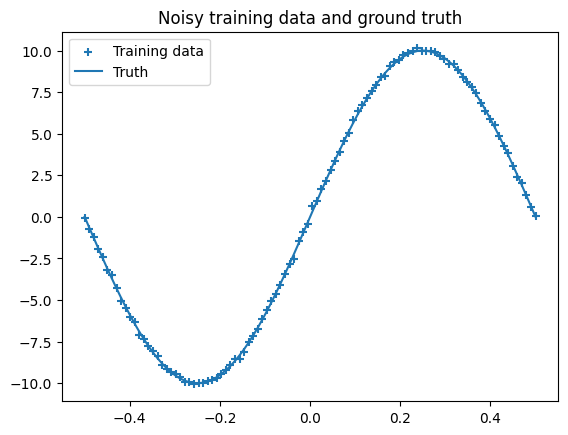

In [32]:
def f(x, sigma):
    epsilon = np.random.randn(*x.shape) * sigma
    return 10*np.sin(2*np.pi*x) + epsilon

train_size = 100
noise = 0.1

X = np.linspace(-0.5, 0.5, train_size).reshape(-1, 1)
y = f(X, sigma=noise)
y_true = f(X, sigma=0.0)

plt.scatter(X, y, marker='+', label='Training data')
plt.plot(X, y_true, label='Truth')
plt.title('Noisy training data and ground truth')
plt.legend()

<img src="photo/FNN_3.png" /> 

In [33]:
def MVG(n) :
    return [np.random.normal() for _ in range(n)]

In [34]:
def simuler_theta(theta, sigma) :
        res = [np.random.normal(loc = s, scale=sigma) for s in theta]
        return res

In [35]:
def FNN(x, theta):
    return (np.tanh(theta[6] + ( theta[2]*np.tanh(theta[4] + x*theta[0]) + theta[3]*np.tanh(theta[5] + x*theta[1])))).reshape(len(x),)

In [36]:
def FNN(x, theta, n) :
    # w_1, w_2, w_3, b_1, b_2, b_3 = theta
    w_1 = theta[:n]
    w_2 = [theta[(k*(n)):(n + k*(n))] for k in range(1,n+1)]
    w_3 = theta[(n+1)*n:(n+1)**2]
    b_1 = theta[(n+1)**2:((n+1)**2+n)]
    b_2 = theta[(n+1)**2 + n:((n+1)**2+2*n)]
    b_3 = theta[-1]
    res = b_3
    for k in range(3) :
        s = b_2[k]
        for j in range(3) :
            s += w_2[j][k]*(np.tanh(b_1[j] + x*w_1[j])) 
        res += w_3[k]*np.tanh(s)
    return res

Text(0.5, 1.0, 'dist : 69.65084066964754')

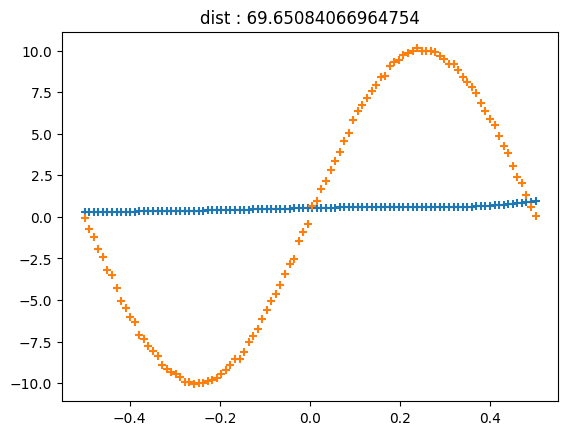

In [37]:
y_h = FNN(X, simuler_theta(MVG(286),1), 15)
plt.scatter(X ,y_h, marker= '+')
plt.scatter(X, y, marker='+', label='Training data')
plt.title("dist : {}".format(np.linalg.norm(y - y_h)))

In [38]:
N = 20000
l = 8
P0 = 0.1
epsilon = 0.1
sigma_j = (l+1)*0.1

import numpy as np
thetas = [simuler_theta([0 for _ in range(286)], 1) for i in range(0, N)]
y_hats = [FNN(X,theta, 15) for theta in thetas]

rho_n = []
for n in range(0, N) :
    rho_n.append(np.linalg.norm(y_hats[n] - y))


for j in range(0, l) : 
    
    new_indices = list(np.argsort(rho_n))
    thetas = list(np.array(thetas)[new_indices])
    y_hats = list(np.array(y_hats)[new_indices])
    rho_n = list(np.array(rho_n)[new_indices])

    epsilon_j = rho_n[int(N*P0)]
    sigma_j = sigma_j - 0.1

    C = 1
    new_thetas = []
    new_y_hats = []
    new_rho_n = []
    for k in range(0, int(N*P0)) :
        mu = thetas[k]

        for i in range(0, int(1/P0) - 1) :
            new_theta = simuler_theta(mu, sigma_j)
            new_y_hat = FNN(X, new_theta, 15)
            rho = np.linalg.norm(new_y_hat - y)
    
            if (rho <= epsilon_j) :
                new_thetas.append(new_theta)
                new_y_hats.append(new_y_hat)
                new_rho_n.append(rho)
                mu = new_theta
            else :
                new_thetas.append(thetas[k])
                new_y_hats.append(y_hats[k])
                new_rho_n.append(rho_n[k])
            C = C+1

    thetas = new_thetas
    y_hats = new_y_hats
    rho_n = new_rho_n

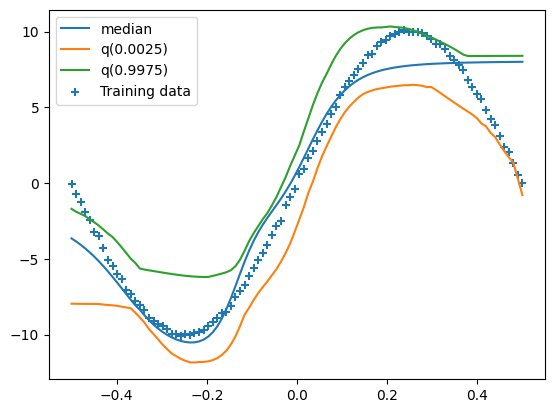

In [50]:
plt.plot(X,np.median(np.array(y_hats), axis = 0), label ="median")
plt.plot(X,np.quantile(np.array(y_hats),q = 0.0025, axis = 0), label = 'q(0.0025)')
plt.plot(X,np.quantile(np.array(y_hats),q = 0.9975, axis = 0), label = 'q(0.9975)')
plt.scatter(X, y, marker='+', label='Training data')
plt.legend()